# 04b – Feature Importance Analyse

Welche Features treiben die lineare Regression (**Model B – mit Zeitfeatures**)?  
Drei komplementäre Methoden:

1. **Korrelationsmatrix** – einfachster Einstieg
2. **Normierte Koeffizienten** – Gewichte der linearen Regression
3. **Permutation Importance** – modell-agnostisch, robuster
4. **Ablation Study** – was kostet es, ein Feature wegzulassen?

> **Voraussetzung:** `04_linear_regression.ipynb` wurde ausgeführt.  
> **Vergleich:** Model A (ohne Zeitfeatures) vs. Model B (mit Zeitfeatures) → H3

## 0 · Setup

In [ ]:
import sys
sys.path.insert(0, '..')

import json
import numpy as np
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.inspection import permutation_importance

from src.data.preprocessing import (
    load_pv_data, load_weather_data, load_irradiance_data,
    merge_features,
)
from src.data.splitting import time_series_split
from src.features.feature_engineering import (
    add_time_features, add_irradiance_features,
)
from src.models.baseline import train_linear_baseline, predict
from src.evaluation.metrics import rmse, mae

P_NOM  = 13_500.0
TARGET = "Solarproduktion"

# Model A: Strahlung + Wetter (ohne Zeitfeatures)
FEATURES_A = [
    "ghi_cloudy_sky", "clear_sky_index",
    "temperature_2m", "cloud_cover_low",
]
# Model B: + zyklische Zeitfeatures (H3)
FEATURES_B = [
    "ghi_cloudy_sky", "clear_sky_index",
    "hour_sin", "hour_cos", "day_sin", "day_cos",
    "temperature_2m", "cloud_cover_low",
]

plt.rcParams.update({"figure.dpi": 120, "axes.grid": True, "grid.alpha": 0.3})

## 1 · Daten & Modell vorbereiten

In [ ]:
pv_df  = load_pv_data()
w_df   = load_weather_data()
irr_df = load_irradiance_data()

df = merge_features(pv_df, w_df, irr_df)
df = add_time_features(df)
df = add_irradiance_features(df)

train, val, _ = time_series_split(df)
train = train.dropna(subset=FEATURES_B + [TARGET])
val   = val.dropna(subset=FEATURES_B + [TARGET])

X_train = train.set_index("timestamp")[FEATURES_B]
y_train = train.set_index("timestamp")[TARGET]
X_val   = val.set_index("timestamp")[FEATURES_B]
y_val   = val.set_index("timestamp")[TARGET]

# Beide Modelle trainieren (für Vergleich in Ablation)
model_a = train_linear_baseline(X_train[FEATURES_A], y_train)
model_b = train_linear_baseline(X_train[FEATURES_B], y_train)
print("Modelle trainiert.")

## 2 · Korrelationsmatrix

Welche Features korrelieren linear mit dem Ziel?  
Analyse auf dem vollen Featureset (Model B = mit Zeitfeatures).

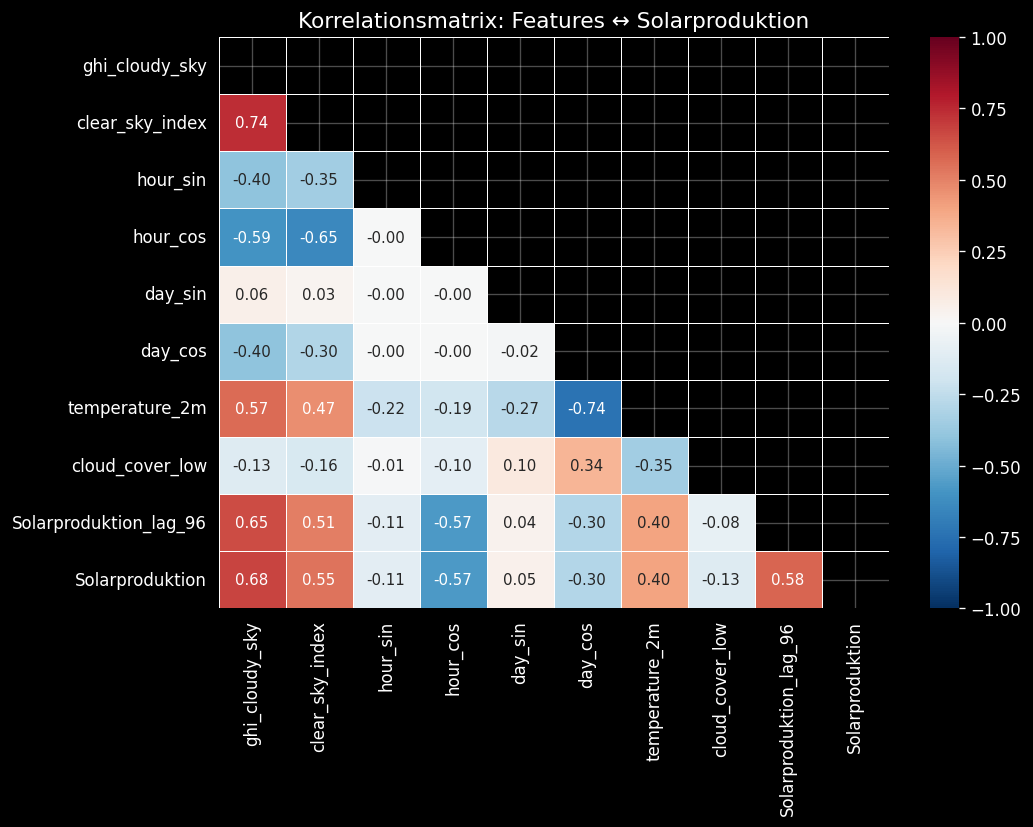


Top-Korrelationen mit Solarproduktion:
ghi_cloudy_sky            0.678
Solarproduktion_lag_96    0.583
hour_cos                  0.574
clear_sky_index           0.546
temperature_2m            0.400
day_cos                   0.295
cloud_cover_low           0.132
hour_sin                  0.108
day_sin                   0.048
Name: Solarproduktion, dtype: float64


In [3]:
corr_cols = FEATURES_B + [TARGET]
corr = train[corr_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.zeros_like(corr, dtype=bool)
mask[np.triu_indices_from(mask)] = True   # nur unteres Dreieck

sns.heatmap(
    corr, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r",
    vmin=-1, vmax=1, linewidths=0.5, ax=ax, annot_kws={"size": 9},
)
ax.set_title("Korrelationsmatrix: Features ↔ Solarproduktion", fontsize=13)
plt.tight_layout()
plt.show()

print("\nTop-Korrelationen mit Solarproduktion:")
print(corr[TARGET].drop(TARGET).abs().sort_values(ascending=False).round(3))

## 3 · Normierte Koeffizienten

Koeffizient × Standardabweichung des Features → über Skalen vergleichbar.  
Interpretation: Um wie viel kW ändert sich die Prognose bei einer **1-σ-Änderung** des Features?

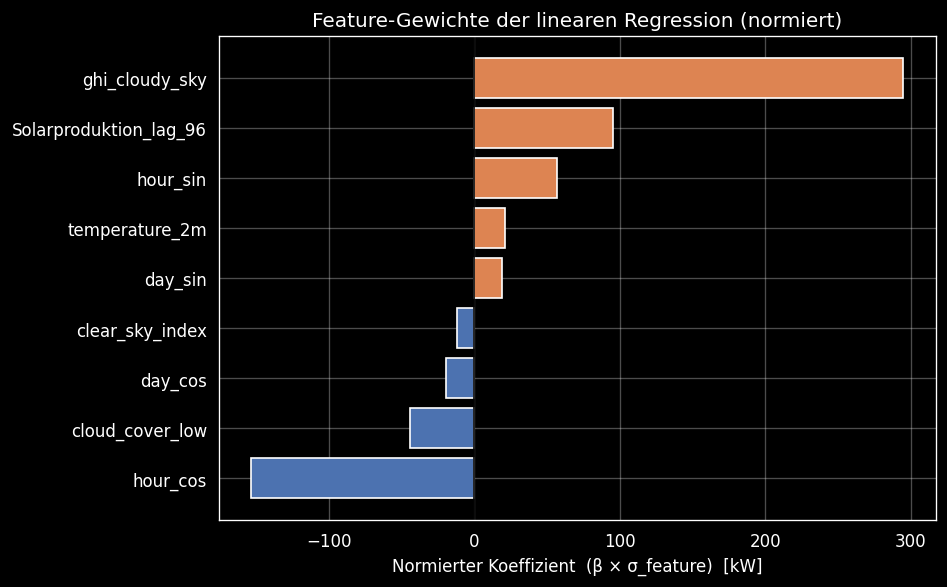

In [4]:
coefs        = model_b.coef_
feature_std  = X_train.std()
normed_coefs = coefs * feature_std.values

coef_df = pd.DataFrame({
    "feature":     FEATURES_B,
    "coefficient": coefs,
    "normed_coef": normed_coefs,
}).set_index("feature").sort_values("normed_coef")

fig, ax = plt.subplots(figsize=(8, 5))
colors = ["#DD8452" if v > 0 else "#4C72B0" for v in coef_df["normed_coef"]]
ax.barh(coef_df.index, coef_df["normed_coef"], color=colors, edgecolor="white")
ax.axvline(0, color="black", linewidth=1)
ax.set_xlabel("Normierter Koeffizient  (β × σ_feature)  [kW]")
ax.set_title("Feature-Gewichte der linearen Regression (normiert)", fontsize=12)
plt.tight_layout()
plt.show()

## 4 · Permutation Importance

Wie stark steigt der MAE, wenn ein Feature zufällig permutiert ("durchmischt") wird?  
Vorteil gegenüber Koeffizienten: erfasst auch Features mit korrelierten Nachbarn robuster.

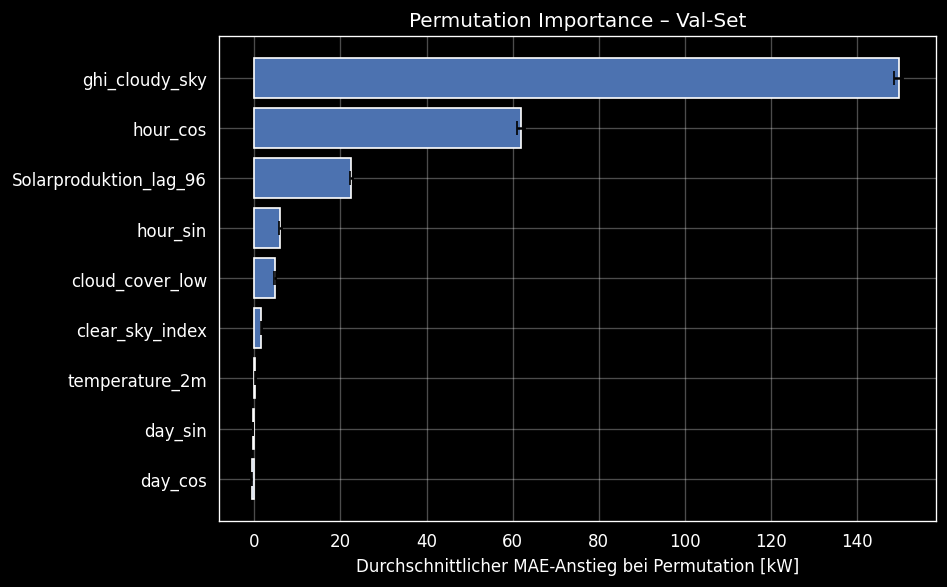


Top-3 Features:
                        importance    std
feature                                  
ghi_cloudy_sky             149.682  1.062
hour_cos                    61.954  0.884
Solarproduktion_lag_96      22.557  0.428


In [5]:
perm = permutation_importance(
    model_b, X_val, y_val,
    n_repeats=15, random_state=42, scoring="neg_mean_absolute_error",
)

perm_df = pd.DataFrame({
    "feature":    FEATURES_B,
    "importance": perm.importances_mean,
    "std":        perm.importances_std,
}).set_index("feature").sort_values("importance", ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(
    perm_df.index[::-1], perm_df["importance"][::-1],
    xerr=perm_df["std"][::-1],
    color="#4C72B0", edgecolor="white", capsize=4,
)
ax.set_xlabel("Durchschnittlicher MAE-Anstieg bei Permutation [kW]")
ax.set_title("Permutation Importance – Val-Set", fontsize=12)
plt.tight_layout()
plt.show()

print("\nTop-3 Features:")
print(perm_df.head(3)[["importance", "std"]].round(3))

## 5 · Ablation Study

Was kostet es an RMSE, wenn jeweils **ein Feature** weggelassen wird?  
Zeigt die marginale Wichtigkeit im Verbund aller Features.

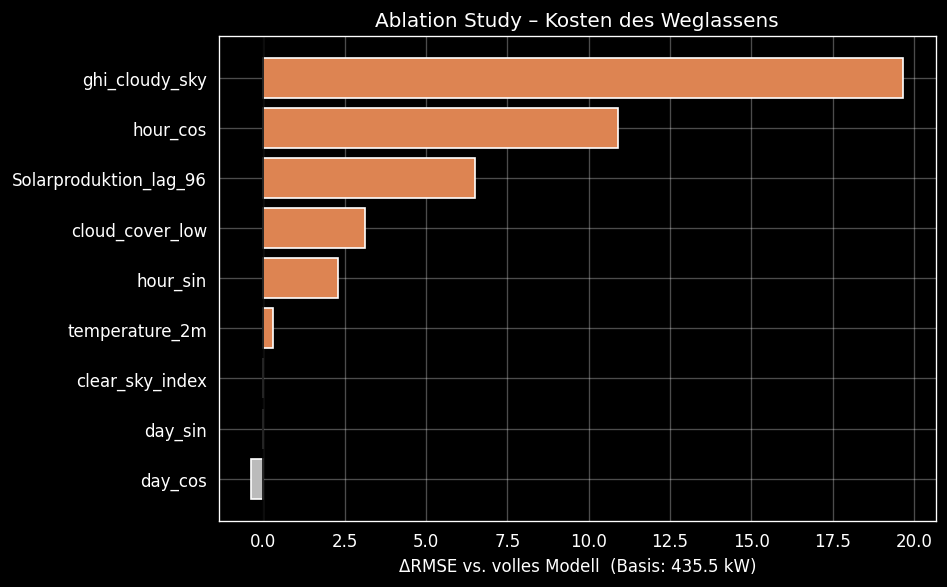

Basis-RMSE (alle Features): 435.51 kW
ghi_cloudy_sky            19.672
hour_cos                  10.890
Solarproduktion_lag_96     6.506
cloud_cover_low            3.120
hour_sin                   2.298
temperature_2m             0.284
clear_sky_index           -0.007
day_sin                   -0.019
day_cos                   -0.376
Name: ΔRMSE [kW], dtype: float64


In [6]:
base_rmse = rmse(y_val, predict(model_b, X_val))
ablation  = {}

for feat in FEATURES_B:
    feats_wo = [f for f in FEATURES_B if f != feat]
    m_wo     = train_linear_baseline(X_train[feats_wo], y_train)
    pred_wo  = predict(m_wo, X_val[feats_wo])
    ablation[feat] = rmse(y_val, pred_wo) - base_rmse

ablation_df = pd.Series(ablation, name="ΔRMSE [kW]").sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
colors = ["#DD8452" if v > 0 else "#bbb" for v in ablation_df]
ax.barh(ablation_df.index[::-1], ablation_df.values[::-1],
        color=colors[::-1], edgecolor="white")
ax.axvline(0, color="black", linewidth=1)
ax.set_xlabel(f"ΔRMSE vs. volles Modell  (Basis: {base_rmse:.1f} kW)")
ax.set_title("Ablation Study – Kosten des Weglassens", fontsize=12)
plt.tight_layout()
plt.show()

print(f"Basis-RMSE (alle Features): {base_rmse:.2f} kW")
print(ablation_df.round(3))

## 6 · Fazit

| Methode | Erwartete Top-Features |
|---|---|
| Korrelation | `ghi_cloudy_sky`, `clear_sky_index`, `hour_sin/cos` |
| Normierte Koeff. | `ghi_cloudy_sky`, `clear_sky_index` |
| Permutation | stärkstes physikalisches Feature |
| Ablation | marginale Kosten je Feature |

**Erkenntnisse (typisch für PV-Prognose):**
1. **Strahlung dominiert** – `ghi_cloudy_sky` in allen Methoden führend
2. **Zeitfeatures** (sin/cos) ergänzen Strahlung und erfassen Tages-/Jahresrhythmus → relevant für H3
3. **→ H4:** Lineare Regression kann nichtlineare GHI-Sättigung nicht erfassen  
   → Nächster Schritt: Random Forest / Gradient Boosting